In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.transpiler import Target, CouplingMap
from qiskit.quantum_info import Operator
from qiskit_device_benchmarking.bench_code.mrb import MirrorQA, QuantumAwesomeness
import os, random
# Fix random seed for numpy
SEED = 123 # pick your favorite int
os.environ["PYTHONHASHSEED"] = str(SEED)  # optional, for hash-based determinism
random.seed(SEED)
np.random.seed(SEED)

# Define parameters for the simulated backend
num_qubits = 156
basis_gates = ["id", "h", "x", "y", "z", "rz", "cx"]
p2 = 1e-2 # 2-qubit gate error probability
p1 = p2/10  # 1-qubit gate error probability
rz_angle = np.pi / 2  # Match initial_entangling_angle
shots = 10000
lengths = [2]+[4,10,20,50,100]
num_samples = 20
 
# Create a coupling map as a list of tuples
# Define the connections (edges) between qubits
fez_edges = [(0, 1), (1, 0), (1, 2), (2, 1), (2, 3), (3, 2), (3, 4), (3, 16), (4, 3), (4, 5), (5, 4), (5, 6), (6, 5), (6, 7), (7, 6), (7, 8), (7, 17), (8, 7), (8, 9), (9, 8), (9, 10), (10, 9), (10, 11), (11, 10), (11, 12), (11, 18), (12, 11), (12, 13), (13, 12), (13, 14), (14, 13), (14, 15), (15, 14), (15, 19), (16, 3), (16, 23), (17, 7), (17, 27), (18, 11), (18, 31), (19, 15), (19, 35), (20, 21), (21, 20), (21, 22), (21, 36), (22, 21), (22, 23), (23, 16), (23, 22), (23, 24), (24, 23), (24, 25), (25, 24), (25, 26), (25, 37), (26, 25), (26, 27), (27, 17), (27, 26), (27, 28), (28, 27), (28, 29), (29, 28), (29, 30), (29, 38), (30, 29), (30, 31), (31, 18), (31, 30), (31, 32), (32, 31), (32, 33), (33, 32), (33, 34), (33, 39), (34, 33), (34, 35), (35, 19), (35, 34), (36, 21), (36, 41), (37, 25), (37, 45), (38, 29), (38, 49), (39, 33), (39, 53), (40, 41), (41, 36), (41, 40), (41, 42), (42, 41), (42, 43), (43, 42), (43, 44), (43, 56), (44, 43), (44, 45), (45, 37), (45, 44), (45, 46), (46, 45), (46, 47), (47, 46), (47, 48), (47, 57), (48, 47), (48, 49), (49, 38), (49, 48), (49, 50), (50, 49), (50, 51), (51, 50), (51, 52), (51, 58), (52, 51), (52, 53), (53, 39), (53, 52), (53, 54), (54, 53), (54, 55), (55, 54), (55, 59), (56, 43), (56, 63), (57, 47), (57, 67), (58, 51), (58, 71), (59, 55), (59, 75), (60, 61), (61, 60), (61, 62), (61, 76), (62, 61), (62, 63), (63, 56), (63, 62), (63, 64), (64, 63), (64, 65), (65, 64), (65, 66), (65, 77), (66, 65), (66, 67), (67, 57), (67, 66), (67, 68), (68, 67), (68, 69), (69, 68), (69, 70), (69, 78), (70, 69), (70, 71), (71, 58), (71, 70), (71, 72), (72, 71), (72, 73), (73, 72), (73, 74), (73, 79), (74, 73), (74, 75), (75, 59), (75, 74), (76, 61), (76, 81), (77, 65), (77, 85), (78, 69), (78, 89), (79, 73), (79, 93), (80, 81), (81, 76), (81, 80), (81, 82), (82, 81), (82, 83), (83, 82), (83, 84), (83, 96), (84, 83), (84, 85), (85, 77), (85, 84), (85, 86), (86, 85), (86, 87), (87, 86), (87, 88), (87, 97), (88, 87), (88, 89), (89, 78), (89, 88), (89, 90), (90, 89), (90, 91), (91, 90), (91, 92), (91, 98), (92, 91), (92, 93), (93, 79), (93, 92), (93, 94), (94, 93), (94, 95), (95, 94), (95, 99), (96, 83), (96, 103), (97, 87), (97, 107), (98, 91), (98, 111), (99, 95), (99, 115), (100, 101), (101, 100), (101, 102), (101, 116), (102, 101), (102, 103), (103, 96), (103, 102), (103, 104), (104, 103), (104, 105), (105, 104), (105, 106), (105, 117), (106, 105), (106, 107), (107, 97), (107, 106), (107, 108), (108, 107), (108, 109), (109, 108), (109, 110), (109, 118), (110, 109), (110, 111), (111, 98), (111, 110), (111, 112), (112, 111), (112, 113), (113, 112), (113, 114), (113, 119), (114, 113), (114, 115), (115, 99), (115, 114), (116, 101), (116, 121), (117, 105), (117, 125), (118, 109), (118, 129), (119, 113), (119, 133), (120, 121), (121, 116), (121, 120), (121, 122), (122, 121), (122, 123), (123, 122), (123, 124), (123, 136), (124, 123), (124, 125), (125, 117), (125, 124), (125, 126), (126, 125), (126, 127), (127, 126), (127, 128), (127, 137), (128, 127), (128, 129), (129, 118), (129, 128), (129, 130), (130, 129), (130, 131), (131, 130), (131, 132), (131, 138), (132, 131), (132, 133), (133, 119), (133, 132), (133, 134), (134, 133), (134, 135), (135, 134), (135, 139), (136, 123), (136, 143), (137, 127), (137, 147), (138, 131), (138, 151), (139, 135), (139, 155), (140, 141), (141, 140), (141, 142), (142, 141), (142, 143), (143, 136), (143, 142), (143, 144), (144, 143), (144, 145), (145, 144), (145, 146), (146, 145), (146, 147), (147, 137), (147, 146), (147, 148), (148, 147), (148, 149), (149, 148), (149, 150), (150, 149), (150, 151), (151, 138), (151, 150), (151, 152), (152, 151), (152, 153), (153, 152), (153, 154), (154, 153), (154, 155), (155, 139), (155, 154)]

# Make bidirectional edges
fez_edges += [(b, a) for (a, b) in fez_edges]
# Create the coupling map
coupling_map = CouplingMap(couplinglist=fez_edges)

# Create a Target object to define the gates, including rz explicitly
target = Target.from_configuration(
    num_qubits=num_qubits,
    basis_gates=basis_gates,
    coupling_map=coupling_map,
    custom_name_mapping={
        "id": Operator(np.array([[1, 0], [0, 1]])),  # Identity gate
        "h": Operator(np.array([[1, 1], [1, -1]]) / np.sqrt(2)),  # Hadamard gate
        "x": Operator(np.array([[0, 1], [1, 0]])),  # Pauli X gate
        "y": Operator(np.array([[0, -1j], [1j, 0]])),  # Pauli Y gate
        "z": Operator(np.array([[1, 0], [0, -1]])),  # Pauli Z gate
        "rz": Operator([[np.cos(rz_angle / 2), -1j*np.sin(rz_angle / 2)],
                        [-1j*np.sin(rz_angle / 2), np.cos(rz_angle / 2)]]),  # RZ(π/2)
        "cx": Operator(np.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]])),  # CNOT gate
    }
)

# Create a noise model to emulate the NoisyBackend
noise_model = NoiseModel()

# Add depolarizing errors for 1-qubit and 2-qubit gates
error_1q = depolarizing_error(p1, 1)
error_2q = depolarizing_error(p2, 2)

# Apply errors to all basis gates except 'delay' and 'reset'
for gate in basis_gates:
    if gate in ["id", "h", "x", "y", "z", "rz"]:
        noise_model.add_all_qubit_quantum_error(error_1q, gate)
    elif gate == "cx":
        noise_model.add_all_qubit_quantum_error(error_2q, gate)

# Set up the AerSimulator with stabilizer method, target, and noise model
backend = AerSimulator(
    method="stabilizer",
    noise_model=noise_model if (p1 > 0 or p2 > 0) else None,
    target=target,
    max_parallel_threads=0,
    max_parallel_experiments=0, seed_simulator=SEED
)

# Set up the experiment object
exp = MirrorQA(
    range(num_qubits),
    lengths=lengths,
    backend=backend,
    two_qubit_gate_density=0.25,
    num_samples=num_samples,
    initial_entangling_angle=np.pi/2, seed=SEED
)

# Set run options
exp.set_run_options(shots=shots)

# Run the experiment 
rb_data = exp.run()
print("Job IDs:", rb_data.job_ids)


Job IDs: ['c3bd8c20-1f9e-4a83-bd44-bfb727365c46']


In [2]:
import os
import json
import qiskit.qasm2

# Get the job id
job_id = rb_data.job_ids[0]
# Create a folder with the job id as name
os.makedirs(job_id, exist_ok=True)
# Save qubit number
with open(f'{job_id}/{job_id}_qubits.json', 'w') as f:
    json.dump({"num_qubits": num_qubits}, f)
# Save pairs
with open(f'{job_id}/{job_id}_pairs.json', 'w') as f:
    json.dump(exp._pairs, f)
# Save seed
with open(f'{job_id}/{job_id}_seed.json', 'w') as f:
    json.dump({"seed": SEED}, f)
# Save circuits
for i, circ in enumerate(exp.circuits()):
    with open(os.path.join(job_id, f'circuit_{i}.json'), 'w') as f:
        qiskit.qasm2.dump(circ, f)

In [20]:
exp.analysis.set_options(analyzed_quantity='Effective Polarization')
analysis = exp.analysis.run(rb_data)

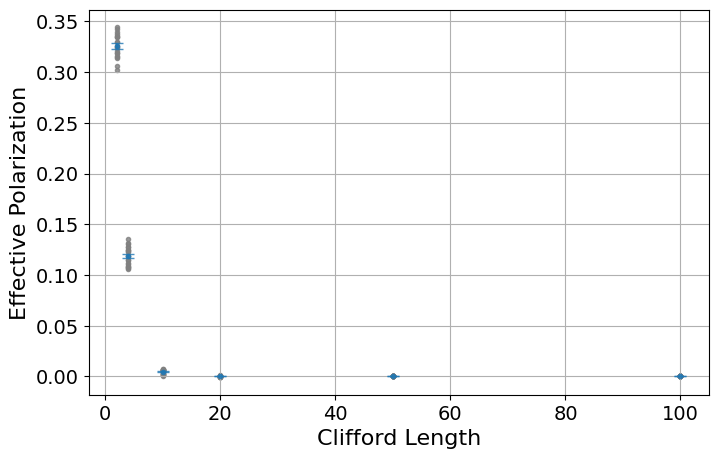

In [24]:
analysis.figure(0)

In [6]:
# Save the MRB plot (extract matplotlib figure from FigureData)
fig = analysis.figure(0).figure
fig.savefig(f'{job_id}/{job_id}_mrb_plot.png', dpi=300, bbox_inches='tight')

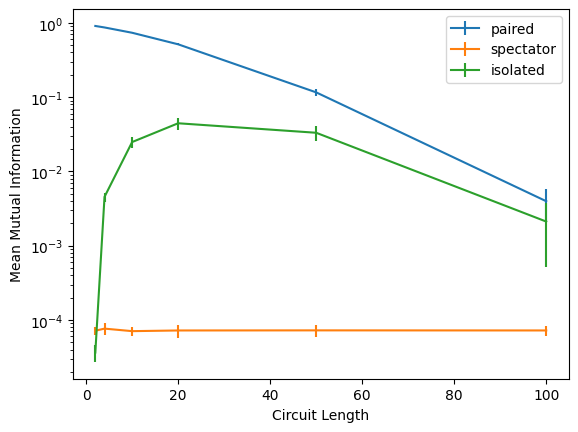

In [7]:
qa = QuantumAwesomeness(exp.backend.coupling_map)
mi = qa.mutual_info(rb_data.data())
mmi = qa.mean_mutual_info(rb_data.data(), exp._pairs)

ys = [[[] for _ in range(6)] for _ in range(3)]
yerrs = [[],[],[]]

for p, pairtype in enumerate(['paired', 'unpaired', 'singles']):
    for j, m in enumerate(mmi[pairtype]):
        # m can be array-like; avoid ambiguous truth-value by checking element-wise NaNs
        m_arr = np.asarray(m)
        # skip if all entries are NaN
        if np.all(np.isnan(m_arr)):
            continue
        # use the mean of the available values (ignoring NaNs) as the representative scalar
        val = np.nanmean(m_arr)
        ys[p][j % 6].append(val)

    for j in range(6):
        if len(ys[p][j]) == 0:
            # no data for this bin -> keep a placeholder (nan) and zero error
            yerrs[p].append(0.0)
            ys[p][j] = np.nan
        else:
            yerrs[p].append(np.std(ys[p][j]))
            ys[p][j] = np.mean(ys[p][j])

plt.errorbar(lengths,ys[0],yerr=yerrs[0],label='paired')
plt.errorbar(lengths,ys[1],yerr=yerrs[1],label='spectator')
plt.errorbar(lengths,ys[2],yerr=yerrs[2],label='isolated')
plt.yscale('log')
plt.legend()
plt.xlabel('Circuit Length')
plt.ylabel('Mean Mutual Information')
plt.title('')

# Save mmi data to folder
mmi_data = {'lengths': lengths,
               'paired': ys[0],
               'spectator': ys[1],
               'isolated': ys[2],
               'paired_err': yerrs[0],
               'spectator_err': yerrs[1],
               'isolated_err': yerrs[2]}
with open(f'{job_id}/{job_id}_mutual_info_data.json', 'w') as f:
    json.dump(mmi_data, f)

# Save MI plot
fig_mi = plt.gcf()
fig_mi.savefig(f'{job_id}/{job_id}_mutual_info_plot.png', dpi=300, bbox_inches='tight')